# Análise de Dados - Câncer de Pulmão

Análise exploratória do dataset de câncer de pulmão usando Python e Machine Learning

## Importação das Bibliotecas

Esta célula importa todas as bibliotecas necessárias para a análise:
- **pandas**: Manipulação e análise de dados tabulares
- **sklearn**: Algoritmos de machine learning (classificação, métricas, pré-processamento)
- **matplotlib.pyplot**: Criação de gráficos básicos
- **seaborn**: Visualizações estatísticas avançadas
- **numpy**: Operações numéricas e arrays

In [261]:
# Importar bibliotecas necessárias
import warnings
import pandas as pd # Para trabalhar com dados tabulares
import numpy as np # Transformação dos dados
import matplotlib.pyplot as plt # Gráficos
import seaborn as sns # Gráficos
import seaborn as sb # Gráficos
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid

warnings.filterwarnings('ignore', category=RuntimeWarning)

try:
    import shap
except ModuleNotFoundError:
    shap = None


## Descrição do Dataset

Este dataset contém informações sobre fatores de risco associados ao câncer de pulmão. As colunas representam:

- **Gênero**: M (masculino), F (feminino)
- **Idade**: Idade do paciente
- **Fumar**: SIM=2, NÃO=1
- **Dedos amarelos**: SIM=2, NÃO=1
- **Ansiedade**: SIM=2, NÃO=1
- **Pressão dos pares**: SIM=2, NÃO=1
- **Doença crônica**: SIM=2, NÃO=1
- **Fadiga**: SIM=2, NÃO=1
- **Alergia**: SIM=2, NÃO=1
- **Chiado no peito**: SIM=2, NÃO=1
- **Álcool**: SIM=2, NÃO=1
- **Tosse**: SIM=2, NÃO=1
- **Falta de ar**: SIM=2, NÃO=1
- **Dificuldade para engolir**: SIM=2, NÃO=1
- **Dor no peito**: SIM=2, NÃO=1
- **Câncer de pulmão**: SIM, NÃO

## Entregáveis e Fonte dos Dados

Este notebook faz parte da entrega final do Tech Challenge e pode ser exportado em PDF para composição do relatório técnico.

- **Repositório Git**: git@github-fiap:fiap-grupo-xpto/fiap-tech-challenge-fase-1.git
- **Dataset utilizado**: [Lung Cancer Dataset](https://www.kaggle.com/datasets/akashnath29/lung-cancer-dataset/data)
- **Código-fonte**: notebook `train_model/analise_cancer.ipynb`
- **Execução local**: consultar o `README.md` e o `Dockerfile` da raiz do projeto

A solução foi organizada para atender aos requisitos de exploração, pré-processamento, modelagem, avaliação e explicabilidade.

## 1. Carregamento dos Dados

Carregando o dataset survey lung cancer em um DataFrame do Pandas

In [262]:
# Carregar os dados
dados = pd.read_csv('dataset.csv', sep=',')

# Compatibilizar nomes de colunas entre versões do dataset
dados.rename(columns={
    'YELLOW_FINGERS': 'YELLOW FINGERS',
    'PEER_PRESSURE': 'PEER PRESSURE',
    'CHRONIC_DISEASE': 'CHRONIC DISEASE',
    'ALCOHOL_CONSUMING': 'ALCOHOL CONSUMING',
    'SHORTNESS_OF_BREATH': 'SHORTNESS OF BREATH',
    'SWALLOWING_DIFFICULTY': 'SWALLOWING DIFFICULTY',
    'CHEST_PAIN': 'CHEST PAIN'
}, inplace=True)

# Visualizar os primeiros registros
dados.head()

,GENDER,AGE,SMOKING,YELLOW FINGERS,ANXIETY,PEER PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


## Carregamento e Primeira Visualização dos Dados

Esta seção carrega o dataset CSV e mostra os primeiros registros para entender a estrutura dos dados.

## 2. Exploração Inicial dos Dados

Analisando as dimensões e verificando valores faltantes

In [263]:
# Dimensões do dataset (linhas, colunas)
print("Dimensões do dataset:")
dados.shape

Dimensões do dataset:


(3000, 16)

## Exploração Inicial dos Dados

Esta seção realiza uma análise preliminar do dataset:
- Verifica as dimensões (número de linhas e colunas)
- Identifica valores nulos/missing
- Mostra informações sobre tipos de dados
- Estatísticas descritivas básicas

In [264]:
print("\nValores nulos por coluna:")
dados.isnull().sum()


Valores nulos por coluna:


GENDER                   0
AGE                      0
SMOKING                  0
YELLOW FINGERS           0
ANXIETY                  0
PEER PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [265]:
print("\nInformações do dataset:")
dados.info()


Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 3000 non-null   str  
 1   AGE                    3000 non-null   int64
 2   SMOKING                3000 non-null   int64
 3   YELLOW FINGERS         3000 non-null   int64
 4   ANXIETY                3000 non-null   int64
 5   PEER PRESSURE          3000 non-null   int64
 6   CHRONIC DISEASE        3000 non-null   int64
 7   FATIGUE                3000 non-null   int64
 8   ALLERGY                3000 non-null   int64
 9   WHEEZING               3000 non-null   int64
 10  ALCOHOL CONSUMING      3000 non-null   int64
 11  COUGHING               3000 non-null   int64
 12  SHORTNESS OF BREATH    3000 non-null   int64
 13  SWALLOWING DIFFICULTY  3000 non-null   int64
 14  CHEST PAIN             3000 non-null   int64
 15  LUNG_CANCER            3

In [266]:
print("\nDescrição estatística dos dados numéricos:")
dados.describe()


Descrição estatística dos dados numéricos:


,AGE,SMOKING,YELLOW FINGERS,ANXIETY,PEER PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,55.169000,1.491000,1.514000,1.494000,1.499000,1.509667,1.489667,1.506667,1.497333,1.491333,1.510667,1.488000,1.489667,1.498667
std,14.723746,0.500002,0.499887,0.500047,0.500082,0.499990,0.499977,0.500039,0.500076,0.500008,0.499970,0.499939,0.499977,0.500082
min,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,42.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,55.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,80.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [267]:
print("\nNúmero de registros duplicados:")
dados.duplicated().sum()


Número de registros duplicados:


2

## Limpeza de Dados

Esta seção trata da limpeza e preparação dos dados:
- Identifica e remove registros duplicados
- Garante qualidade dos dados para análise

In [268]:
dados.drop_duplicates(inplace=True)

In [269]:

print("\nContagem de valores únicos na coluna 'GENDER':")
print("Para indentificar o nuúmero de registros masculinos e femininos:")
dados['GENDER'].value_counts()


Contagem de valores únicos na coluna 'GENDER':
Para indentificar o nuúmero de registros masculinos e femininos:


GENDER
M    1512
F    1486
Name: count, dtype: int64

In [270]:

print("\nContagem de valores únicos na coluna 'LUNG_CANCER':")
print("Para identificar o número de registros com e sem câncer de pulmão:")
dados['LUNG_CANCER'].value_counts()


Contagem de valores únicos na coluna 'LUNG_CANCER':
Para identificar o número de registros com e sem câncer de pulmão:


LUNG_CANCER
YES    1517
NO     1481
Name: count, dtype: int64

In [271]:
print("Contagem dos valores únicos por idade:")
dados['AGE'].value_counts()

Contagem dos valores únicos por idade:


AGE
54    73
67    71
75    71
47    70
69    70
55    69
78    69
79    68
32    66
39    65
37    65
53    65
77    64
46    64
63    63
33    62
50    62
70    61
68    61
35    60
48    60
36    60
76    59
71    59
31    59
62    58
57    58
56    58
60    57
80    57
34    57
52    57
61    57
64    56
41    56
42    56
49    56
51    55
59    55
43    55
44    54
38    53
58    51
40    51
74    50
65    49
66    48
45    47
72    46
73    43
30    42
Name: count, dtype: int64

In [272]:
Total = len(dados)
temCancer = dados[dados["LUNG_CANCER"] == 'YES'].LUNG_CANCER.count()
naoTemCancer = dados[dados["LUNG_CANCER"] == 'NO'].LUNG_CANCER.count()

Percentual_tem_cancer = temCancer / Total 

print("Total de dados: ", Total)
print("Total de pessoas que não tem cancer: ", naoTemCancer)
print("Total de pessoas que tem cancer: ", temCancer)
print("Percentual que tem cancer: ", (round(Percentual_tem_cancer, 2)*100), "%")

Total de dados:  2998
Total de pessoas que não tem cancer:  1481
Total de pessoas que tem cancer:  1517
Percentual que tem cancer:  51.0 %


## Análise da Variável Alvo (Câncer de Pulmão)

Esta seção analisa a distribuição da variável dependente:
- Contagem de casos positivos e negativos
- Cálculo de percentuais
- Visualização com gráfico de pizza


Distribuição de câncer de pulmão:


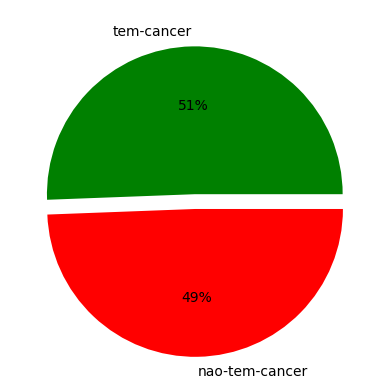

In [273]:

print("\nDistribuição de câncer de pulmão:")
categororias = ["tem-cancer", "nao-tem-cancer"]
plt.pie(dados["LUNG_CANCER"].value_counts(), labels = categororias, autopct = "%.0f%%", explode= (0, 0.1), colors = ("g", "r"))
plt.show()

In [274]:
totalTemCancer = dados[dados["LUNG_CANCER"] == 'YES']

## Análise dos Pacientes com Câncer

Esta seção foca nos pacientes diagnosticados com câncer:
- Filtra apenas casos positivos
- Mostra estatísticas descritivas dos fatores de risco
- Cria visualizações dos padrões encontrados

In [275]:
totalTemCancer.head()

,GENDER,AGE,SMOKING,YELLOW FINGERS,ANXIETY,PEER PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
5,F,58,1,1,1,2,2,2,2,1,2,2,1,1,2,YES
6,F,70,1,1,1,2,2,1,2,2,2,2,2,2,1,YES
11,F,60,2,2,1,1,1,1,2,2,2,1,1,2,1,YES


In [276]:

print("\nDescrição estatística dos registros com câncer de pulmão:")
totalTemCancer.describe().T


Descrição estatística dos registros com câncer de pulmão:


,count,mean,std,min,25%,50%,75%,max
AGE,1517.0,54.652604,14.907541,30.0,41.0,54.0,68.0,80.0
SMOKING,1517.0,1.498352,0.500162,1.0,1.0,1.0,2.0,2.0
YELLOW FINGERS,1517.0,1.520765,0.499733,1.0,1.0,2.0,2.0,2.0
ANXIETY,1517.0,1.487146,0.500000,1.0,1.0,1.0,2.0,2.0
PEER PRESSURE,1517.0,1.486486,0.499982,1.0,1.0,1.0,2.0,2.0
CHRONIC DISEASE,1517.0,1.504944,0.500140,1.0,1.0,2.0,2.0,2.0
FATIGUE,1517.0,1.490442,0.500073,1.0,1.0,1.0,2.0,2.0
ALLERGY,1517.0,1.510218,0.500060,1.0,1.0,2.0,2.0,2.0
WHEEZING,1517.0,1.477917,0.499677,1.0,1.0,1.0,2.0,2.0
ALCOHOL CONSUMING,1517.0,1.475939,0.499585,1.0,1.0,1.0,2.0,2.0


<Axes: xlabel='COUGHING', ylabel='count'>

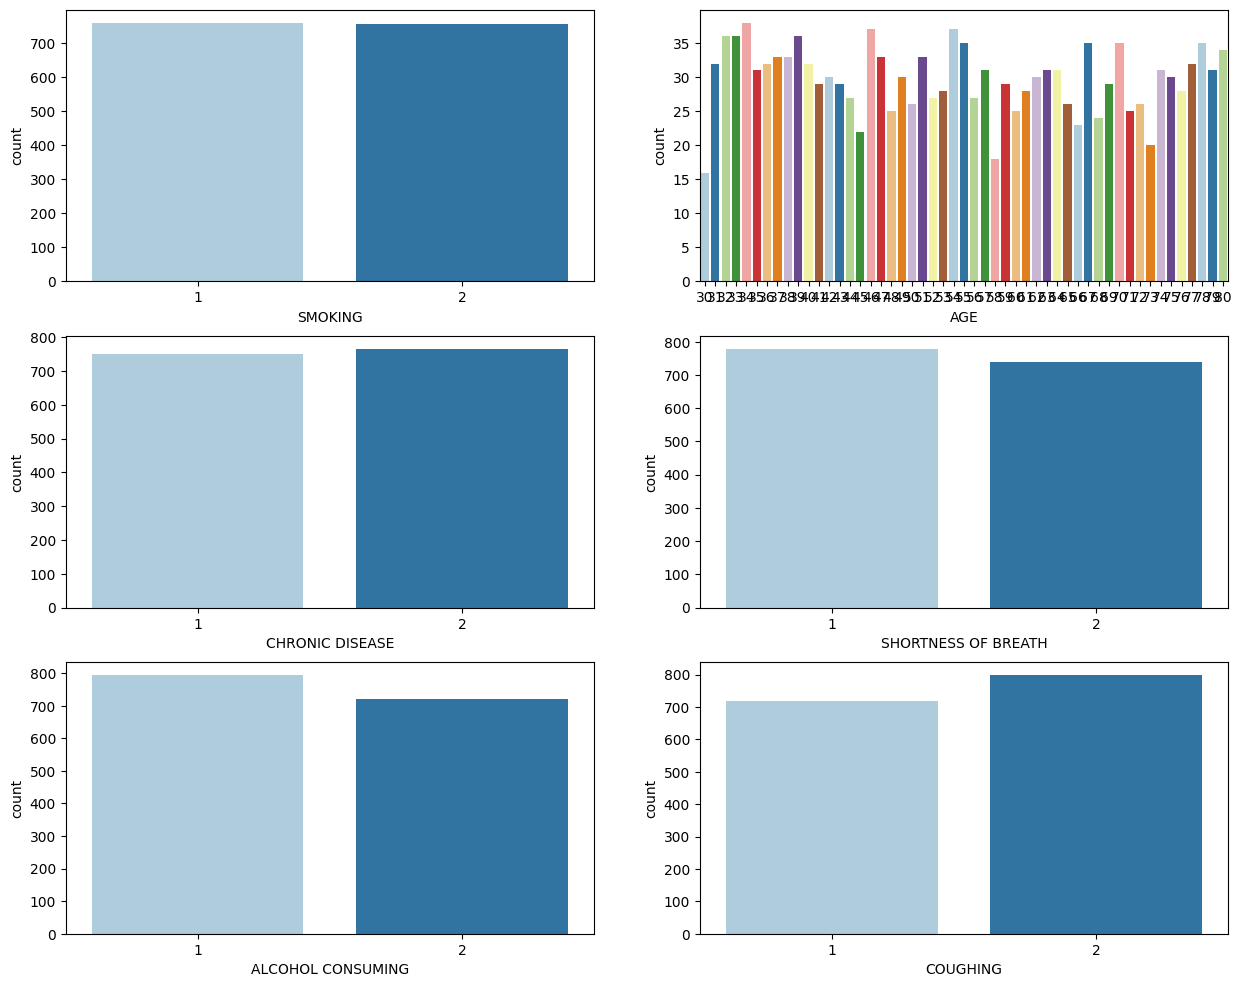

In [277]:
plt.figure(figsize = (15,12))

plt.subplot(3,2,1)
sns.countplot(x = "SMOKING", hue="SMOKING", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,2)
sns.countplot(x = "AGE", hue="AGE", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,3)
sns.countplot(x = "CHRONIC DISEASE", hue="CHRONIC DISEASE", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,4)
sns.countplot(x = "SHORTNESS OF BREATH", hue="SHORTNESS OF BREATH", palette = "Paired", data = totalTemCancer, legend=False)

plt.subplot(3,2,5)
sns.countplot(x = "ALCOHOL CONSUMING", hue="ALCOHOL CONSUMING", palette = "Paired", data = totalTemCancer, legend=False)

plt.subplot(3,2,6)
sns.countplot(x = "COUGHING", hue="COUGHING", palette = "Paired", data = totalTemCancer, legend=False)


/var/folders/t4/3td2bmbs6h38d0yjvn8hwfjn_473md/T/ipykernel_72038/1999815708.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='LUNG_CANCER', y='SMOKING', data=dados, palette='hls')


<Axes: xlabel='LUNG_CANCER', ylabel='SMOKING'>

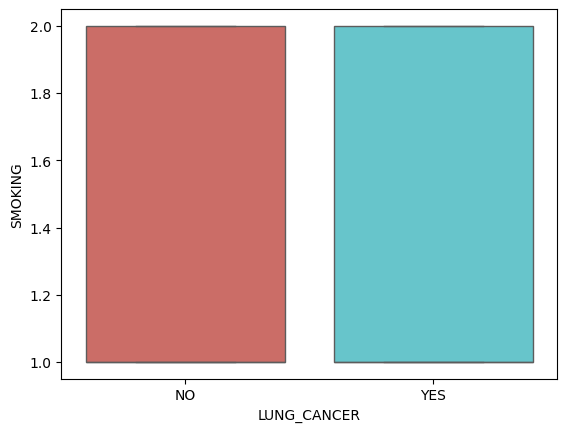

In [278]:


sb.boxplot(x='LUNG_CANCER', y='SMOKING', data=dados, palette='hls')

<Axes: xlabel='AGE'>

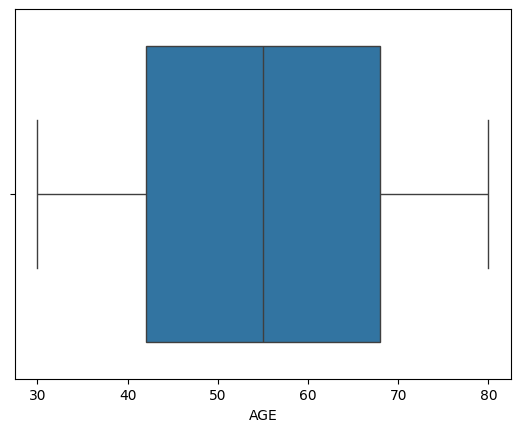

In [279]:
sb.boxplot(x=dados["AGE"])

## Visualizações dos Fatores de Risco

Esta seção cria gráficos para entender os fatores de risco:
- Gráficos de barras mostrando distribuição dos fatores
- Histogramas para variáveis numéricas
- Análise visual dos padrões nos pacientes com câncer

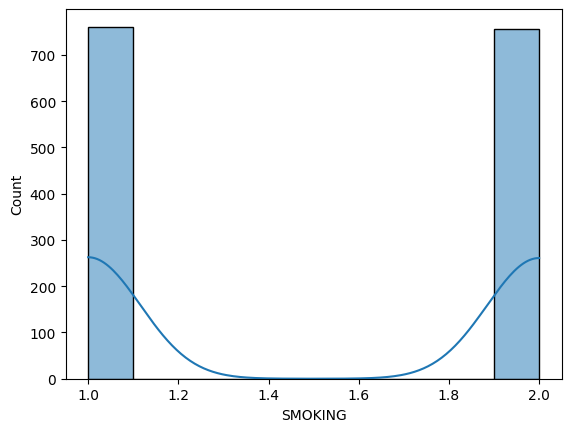

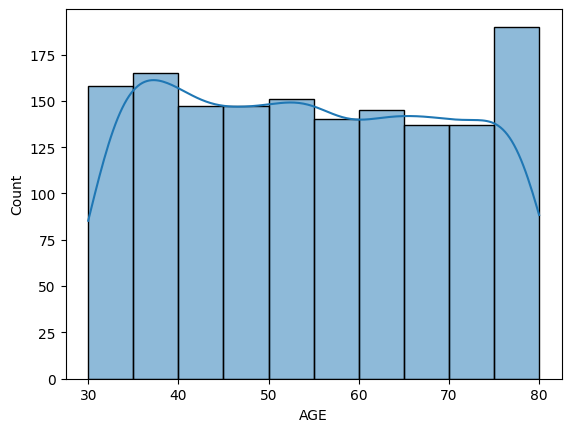

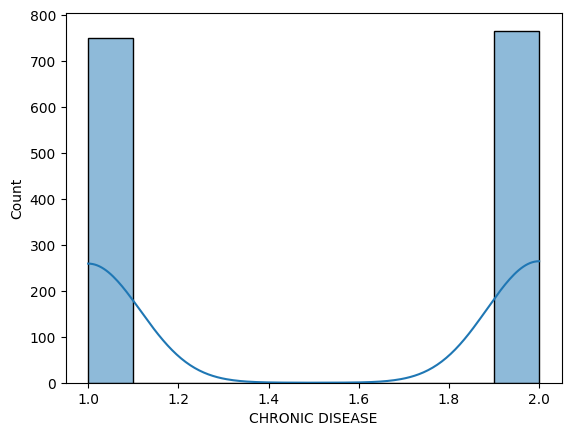

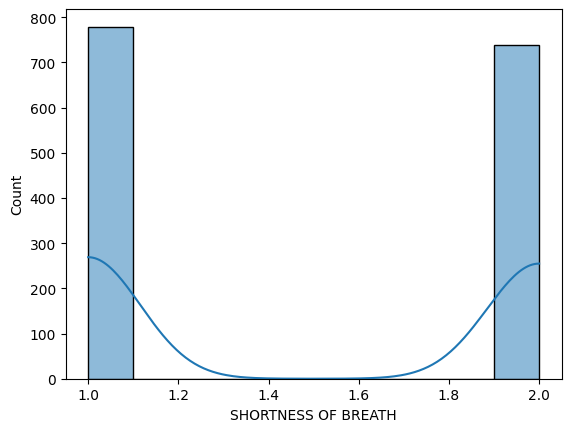

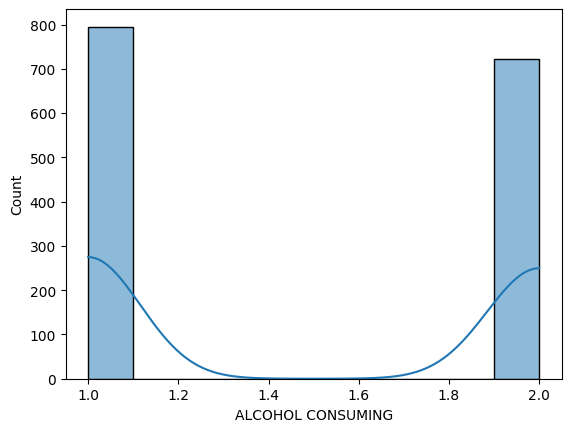

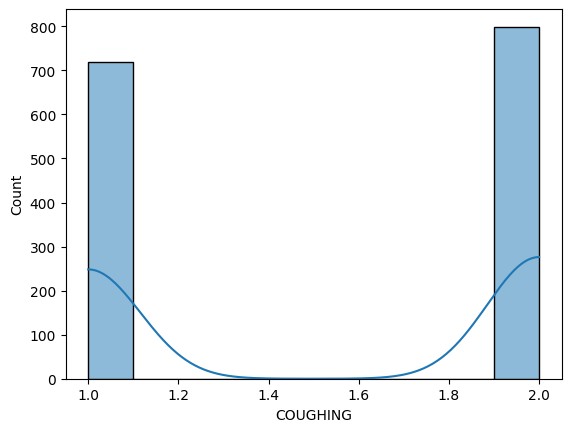

In [280]:
Colunas_Numericas = ["SMOKING", "AGE", "CHRONIC DISEASE", "SHORTNESS OF BREATH", "ALCOHOL CONSUMING", "COUGHING"]
for column in Colunas_Numericas:
    plt.figure()
    plot = totalTemCancer[column]
    sns.histplot(plot, bins=10, kde=True)
    plt.show()

In [281]:
dados_correlacao = dados.copy()

le_genero = LabelEncoder()
le_alvo = LabelEncoder()

dados_correlacao['GENDER'] = le_genero.fit_transform(dados_correlacao['GENDER'])
dados_correlacao['LUNG_CANCER'] = le_alvo.fit_transform(dados_correlacao['LUNG_CANCER'])

## Análise de Correlação

Esta seção analisa as relações entre os fatores de risco:
- Calcula correlação de Pearson entre variáveis numéricas
- Cria heatmap para visualizar associações
- Ordena as variáveis pela força de correlação com `LUNG_CANCER`
- Destaca visualmente quais fatores têm maior associação com o diagnóstico

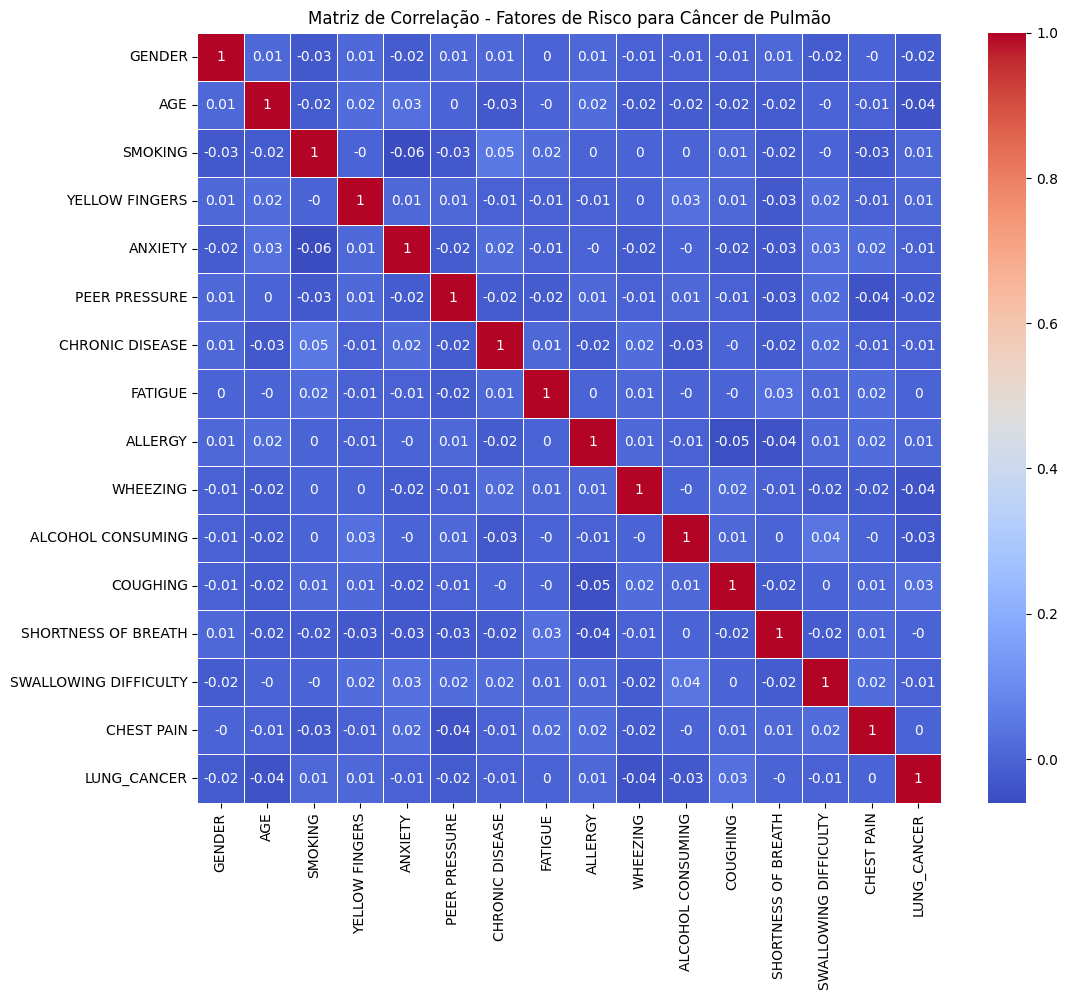

In [282]:
# Calcular correlação apenas para colunas numéricas
correlation_matrix = dados_correlacao.select_dtypes(include=[np.number]).corr().round(2)

fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax, cmap='coolwarm')
plt.title('Matriz de Correlação - Fatores de Risco para Câncer de Pulmão')
plt.show()

Correlação das variáveis com LUNG_CANCER:


,correlacao
AGE,-0.04
WHEEZING,-0.04
ALCOHOL CONSUMING,-0.03
COUGHING,0.03
GENDER,-0.02
PEER PRESSURE,-0.02
SMOKING,0.01
YELLOW FINGERS,0.01
ANXIETY,-0.01
CHRONIC DISEASE,-0.01


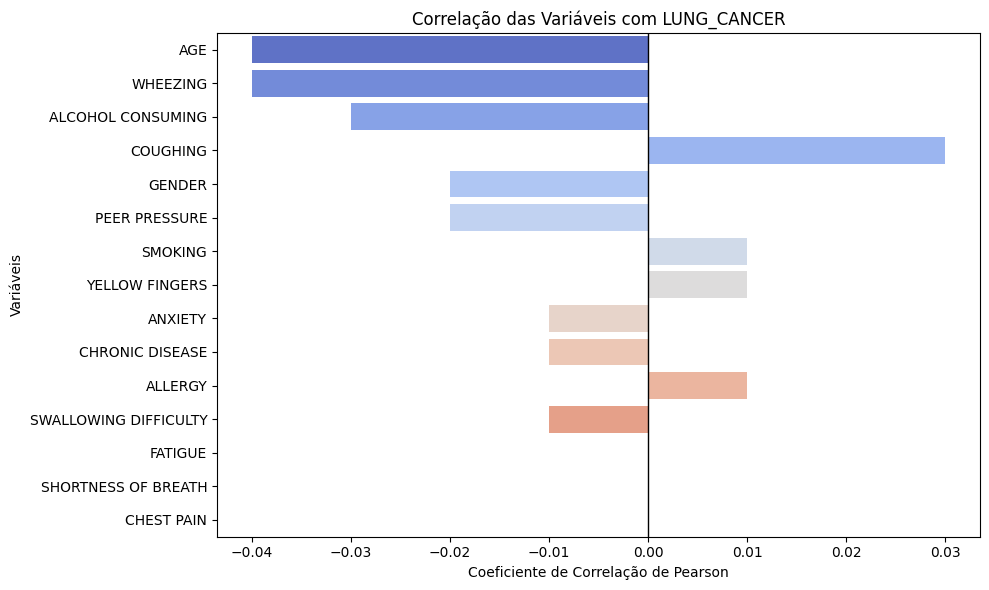

In [283]:
# Destacar a correlação das variáveis com a variável alvo
correlacao_com_cancer = correlation_matrix['LUNG_CANCER'].drop('LUNG_CANCER')
correlacao_com_cancer = correlacao_com_cancer.reindex(correlacao_com_cancer.abs().sort_values(ascending=False).index)

print('Correlação das variáveis com LUNG_CANCER:')
display(correlacao_com_cancer.to_frame(name='correlacao'))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlacao_com_cancer.values, y=correlacao_com_cancer.index, hue=correlacao_com_cancer.index, palette='coolwarm', legend=False)
plt.title('Correlação das Variáveis com LUNG_CANCER')
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.ylabel('Variáveis')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

## Preparação para Modelagem

Nesta etapa, os dados são preparados para o treinamento dos modelos:
- Define-se a variável alvo e as variáveis explicativas;
- Cria-se um pipeline de pré-processamento para variáveis categóricas e numéricas;
- Realiza-se a separação entre **treino, validação e teste**, mantendo a proporção da classe alvo com estratificação.

O conjunto de treino será usado para ajustar os modelos, o conjunto de validação para comparar modelos e ajustar hiperparâmetros, e o conjunto de teste ficará reservado apenas para a avaliação final.


In [284]:
# Preparar os dados para a modelagem
dados_modelagem = dados.drop_duplicates().copy()

X = dados_modelagem.drop(columns=['LUNG_CANCER'])
y = dados_modelagem['LUNG_CANCER'].map({'NO': 0, 'YES': 1})

colunas_categoricas = X.select_dtypes(include=['object', 'string']).columns.tolist()
colunas_numericas = [coluna for coluna in X.columns if coluna not in colunas_categoricas]

preprocessador = ColumnTransformer(
    transformers=[
        ('categoricas', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), colunas_categoricas),
        ('numericas', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), colunas_numericas)
    ]
)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print(f'Formato de X_train: {X_train.shape}')
print(f'Formato de X_val: {X_val.shape}')
print(f'Formato de X_test: {X_test.shape}')

print('\nDistribuição da classe alvo no treino:')
print(y_train.value_counts(normalize=True).rename(index={0: 'NO', 1: 'YES'}))

print('\nDistribuição da classe alvo na validação:')
print(y_val.value_counts(normalize=True).rename(index={0: 'NO', 1: 'YES'}))

print('\nDistribuição da classe alvo no teste:')
print(y_test.value_counts(normalize=True).rename(index={0: 'NO', 1: 'YES'}))

Formato de X_train: (1798, 15)
Formato de X_val: (600, 15)
Formato de X_test: (600, 15)

Distribuição da classe alvo no treino:
LUNG_CANCER
YES    0.505562
NO     0.494438
Name: proportion, dtype: float64

Distribuição da classe alvo na validação:
LUNG_CANCER
YES    0.506667
NO     0.493333
Name: proportion, dtype: float64

Distribuição da classe alvo no teste:
LUNG_CANCER
YES    0.506667
NO     0.493333
Name: proportion, dtype: float64


## Modelagem Preditiva

Foram escolhidas quatro técnicas de classificação para comparação porque este problema é tabular e pequeno, e modelos diferentes reagem de formas diferentes aos mesmos dados.

Como estamos falando de câncer, errar deixando passar um caso positivo é mais grave do que gerar um alerta extra. Por isso, nesta etapa, a prioridade clínica é detectar o máximo possível de casos suspeitos, mesmo que isso reduza a precisão e aumente os falsos positivos.


In [285]:
# Treinar diferentes modelos de classificação
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=700, random_state=42, class_weight='balanced', n_jobs=1)
}

modelos_treinados = {}
predicoes_validacao = {}
resultados_modelos = []

for nome_modelo, estimador in modelos.items():
    pipeline_modelo = Pipeline([
        ('preprocessador', preprocessador),
        ('classificador', estimador)
    ])

    pipeline_modelo.fit(X_train, y_train)

    y_pred = pipeline_modelo.predict(X_val)

    modelos_treinados[nome_modelo] = pipeline_modelo
    predicoes_validacao[nome_modelo] = y_pred

    resultados_modelos.append({
        'Modelo': nome_modelo,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred, zero_division=0),
        'F1-score': f1_score(y_val, y_pred, zero_division=0)
    })

resultados_modelos_df = pd.DataFrame(resultados_modelos).sort_values(
    by=['Recall', 'F1-score', 'Accuracy'],
    ascending=False
)

display(resultados_modelos_df.round(3))

melhor_modelo_inicial = resultados_modelos_df.iloc[0]['Modelo']
print(f'Melhor modelo inicial pelo critério principal na validação (Recall): {melhor_modelo_inicial}')


,Modelo,Accuracy,Recall,F1-score
3,Extra Trees,0.513,0.549,0.534
1,KNN,0.518,0.530,0.527
2,Random Forest,0.503,0.523,0.516
0,Regressão Logística,0.493,0.470,0.485


Melhor modelo inicial pelo critério principal na validação (Recall): Extra Trees


## Avaliação dos Modelos na Validação

As métricas foram escolhidas para refletir o problema real:
- **Recall**: principal métrica aqui, porque mede quantos casos positivos o modelo consegue encontrar.
- **F1-score**: ajuda a equilibrar recall e precisão.
- **Accuracy**: aparece como referência, mas sozinha pode enganar quando o objetivo é não perder casos de câncer.

Nesta etapa, comparamos os modelos no conjunto de validação. O teste continua reservado para a avaliação final.



Relatório de classificação - Regressão Logística
              precision    recall  f1-score   support

          NO       0.49      0.52      0.50       296
         YES       0.50      0.47      0.48       304

    accuracy                           0.49       600
   macro avg       0.49      0.49      0.49       600
weighted avg       0.49      0.49      0.49       600



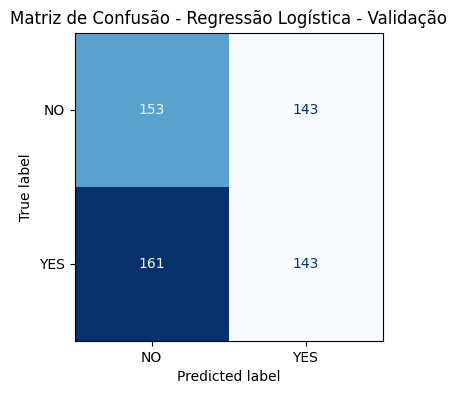


Relatório de classificação - KNN
              precision    recall  f1-score   support

          NO       0.51      0.51      0.51       296
         YES       0.52      0.53      0.53       304

    accuracy                           0.52       600
   macro avg       0.52      0.52      0.52       600
weighted avg       0.52      0.52      0.52       600



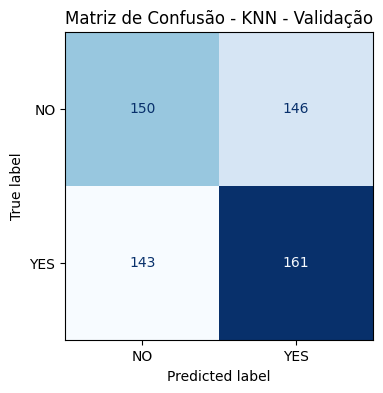


Relatório de classificação - Random Forest
              precision    recall  f1-score   support

          NO       0.50      0.48      0.49       296
         YES       0.51      0.52      0.52       304

    accuracy                           0.50       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.50      0.50      0.50       600



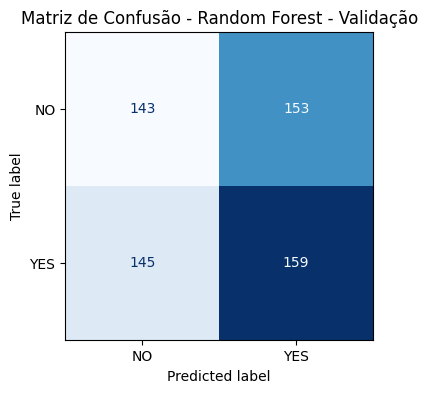


Relatório de classificação - Extra Trees
              precision    recall  f1-score   support

          NO       0.51      0.48      0.49       296
         YES       0.52      0.55      0.53       304

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.51      0.51      0.51       600



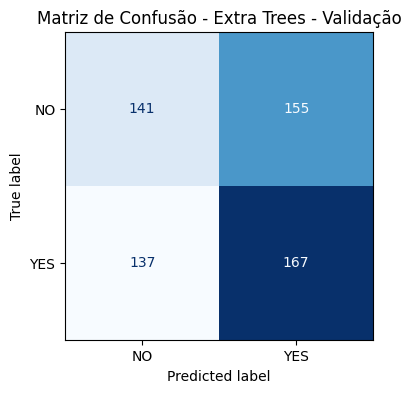

In [286]:
# Exibir relatório de classificação e matriz de confusão para cada modelo na validação
for nome_modelo, y_pred in predicoes_validacao.items():
    print(f'\nRelatório de classificação - {nome_modelo}')
    print(classification_report(
        y_val,
        y_pred,
        target_names=['NO', 'YES'],
        zero_division=0
    ))

    fig, ax = plt.subplots(figsize=(4, 4))
    matriz = confusion_matrix(y_val, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=['NO', 'YES']
    )

    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusão - {nome_modelo} - Validação')
    plt.show()

## Ajuste de Hiperparâmetros Básicos

Nesta etapa, foram testadas diferentes configurações para os modelos utilizados. O objetivo foi escolher a melhor combinação de hiperparâmetros com base no desempenho no conjunto de validação, sempre priorizando recall para reduzir a chance de falso negativo.

O conjunto de teste permaneceu separado e será utilizado apenas na avaliação final.

Como o problema é de triagem clínica, o limiar de decisão também será ajustado na validação para privilegiar a identificação de casos positivos.


In [287]:
# Ajuste de hiperparâmetros básicos usando o conjunto de validação
configuracoes_modelos = {
    'Regressão Logística': {
        'estimador': LogisticRegression(max_iter=2000, class_weight='balanced'),
        'parametros': {
            'classificador__C': [0.1, 1, 10],
            'classificador__solver': ['liblinear']
        }
    },
    'KNN': {
        'estimador': KNeighborsClassifier(),
        'parametros': {
            'classificador__n_neighbors': [3, 5, 7, 9],
            'classificador__weights': ['uniform', 'distance']
        }
    },
    'Random Forest': {
        'estimador': RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=1),
        'parametros': {
            'classificador__n_estimators': [100, 200],
            'classificador__max_depth': [None, 10],
            'classificador__min_samples_split': [2, 5]
        }
    },
    'Extra Trees': {
        'estimador': ExtraTreesClassifier(random_state=42, class_weight='balanced', n_jobs=1),
        'parametros': {
            'classificador__n_estimators': [300, 700],
            'classificador__max_depth': [None, 10],
            'classificador__min_samples_leaf': [1, 2]
        }
    }
}

resultados_hiperparametros = []
modelos_ajustados = {}

melhor_modelo_final = None
melhor_modelo_nome = None
melhores_parametros = None
melhor_criterio = (-1, -1, -1)

for nome_modelo, configuracao in configuracoes_modelos.items():
    melhor_modelo_do_tipo = None
    melhor_parametros_do_tipo = None
    melhor_criterio_do_tipo = (-1, -1, -1)

    for parametros in ParameterGrid(configuracao['parametros']):
        pipeline_modelo = Pipeline([
            ('preprocessador', preprocessador),
            ('classificador', configuracao['estimador'])
        ])

        pipeline_modelo.set_params(**parametros)
        pipeline_modelo.fit(X_train, y_train)

        y_pred_val = pipeline_modelo.predict(X_val)

        accuracy = accuracy_score(y_val, y_pred_val)
        recall = recall_score(y_val, y_pred_val, zero_division=0)
        f1 = f1_score(y_val, y_pred_val, zero_division=0)

        criterio = (recall, f1, accuracy)

        resultados_hiperparametros.append({
            'Modelo': nome_modelo,
            'Parâmetros': parametros,
            'Accuracy': accuracy,
            'Recall': recall,
            'F1-score': f1
        })

        if criterio > melhor_criterio_do_tipo:
            melhor_criterio_do_tipo = criterio
            melhor_modelo_do_tipo = pipeline_modelo
            melhor_parametros_do_tipo = parametros

        if criterio > melhor_criterio:
            melhor_criterio = criterio
            melhor_modelo_final = pipeline_modelo
            melhor_modelo_nome = nome_modelo
            melhores_parametros = parametros

    modelos_ajustados[nome_modelo] = melhor_modelo_do_tipo

resultados_hiperparametros_df = pd.DataFrame(resultados_hiperparametros).sort_values(
    by=['Recall', 'F1-score', 'Accuracy'],
    ascending=False
)

display(resultados_hiperparametros_df.round(3))

print(f'Melhor modelo após ajuste de hiperparâmetros: {melhor_modelo_nome}')
print('Melhores parâmetros:')
print(melhores_parametros)


,Modelo,Parâmetros,Accuracy,Recall,F1-score
19,Extra Trees,"{'classificador__max_depth': None, 'classifica...",0.518,0.549,0.536
20,Extra Trees,"{'classificador__max_depth': None, 'classifica...",0.513,0.549,0.534
6,KNN,"{'classificador__n_neighbors': 5, 'classificad...",0.532,0.546,0.542
4,KNN,"{'classificador__n_neighbors': 3, 'classificad...",0.530,0.546,0.541
23,Extra Trees,"{'classificador__max_depth': 10, 'classificado...",0.515,0.543,0.531
3,KNN,"{'classificador__n_neighbors': 3, 'classificad...",0.525,0.539,0.535
5,KNN,"{'classificador__n_neighbors': 5, 'classificad...",0.525,0.539,0.535
16,Random Forest,"{'classificador__max_depth': 10, 'classificado...",0.493,0.536,0.517
8,KNN,"{'classificador__n_neighbors': 7, 'classificad...",0.528,0.533,0.534
24,Extra Trees,"{'classificador__max_depth': 10, 'classificado...",0.515,0.533,0.527


Melhor modelo após ajuste de hiperparâmetros: Extra Trees
Melhores parâmetros:
{'classificador__max_depth': None, 'classificador__min_samples_leaf': 1, 'classificador__n_estimators': 300}


## Avaliação Final no Conjunto de Teste

Nesta etapa, o limiar de decisão é escolhido com foco clínico: primeiro garantir um recall alto na validação para evitar falso negativo, e só depois observar o impacto disso em falsos positivos.

Em linguagem simples, isso significa que o modelo pode disparar mais alertas do que o ideal, mas evita deixar passar casos suspeitos de câncer. O conjunto de teste é usado apenas aqui para medir esse comportamento em dados novos.


Selecionando o menor limiar com recall >= 0.99 na validação para reduzir ao máximo o risco de falso negativo.


,Limiar,Accuracy,Precision,Recall,Specificity,False Negatives,False Positives,F1-score
0,0.230,0.503,0.505,0.990,0.003,3,295,0.669
1,0.238,0.503,0.505,0.987,0.007,4,294,0.668
2,0.246,0.500,0.503,0.980,0.007,6,294,0.665
3,0.253,0.498,0.503,0.977,0.007,7,294,0.664
4,0.261,0.498,0.503,0.977,0.007,7,294,0.664
5,0.269,0.497,0.502,0.970,0.010,9,293,0.661
6,0.277,0.502,0.504,0.967,0.024,10,289,0.663
7,0.284,0.502,0.504,0.961,0.030,12,287,0.661
8,0.292,0.503,0.505,0.954,0.041,14,284,0.661
10,0.308,0.505,0.506,0.951,0.047,15,282,0.661


Limiar escolhido na validação: 0.23 - este valor será aplicado ao teste.
A tabela abaixo compara o ponto de corte padrão com o ponto de corte escolhido na validação. A parte acima é a análise na validação; a parte abaixo é o resultado no teste.


,Cenário,Modelo final,Threshold,Accuracy,Precision,Recall,Specificity,False Negatives,False Positives,F1-score
0,Padrão 0.5,Extra Trees,0.50,0.505,0.512,0.484,0.527,157,140,0.497
1,Threshold validado,Extra Trees,0.23,0.505,0.506,0.993,0.003,2,295,0.670


Relatório de classificação do modelo final: Extra Trees (threshold 0.23)
              precision    recall  f1-score   support

          NO       0.33      0.00      0.01       296
         YES       0.51      0.99      0.67       304

    accuracy                           0.51       600
   macro avg       0.42      0.50      0.34       600
weighted avg       0.42      0.51      0.34       600

Casos positivos que o modelo deixou passar (falsos negativos): 2


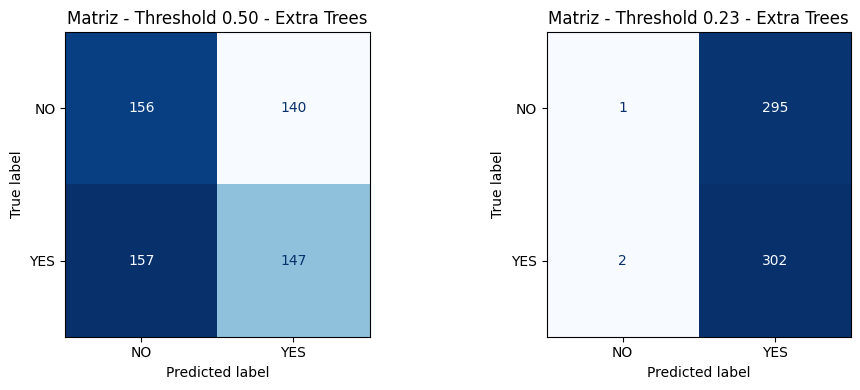

In [ ]:
# Avaliação final do melhor modelo no conjunto de teste
y_pred_teste_padrao = melhor_modelo_final.predict(X_test)

limiar_recuperacao_minima = 0.99
melhor_limiar = 0.5
if hasattr(melhor_modelo_final.named_steps['classificador'], 'predict_proba'):
    probabilidades_validacao = melhor_modelo_final.predict_proba(X_val)[:, 1]
    resultados_limiar = []

    for limiar in np.linspace(0.15, 0.99, 99):
        y_pred_val_limiar = (probabilidades_validacao >= limiar).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred_val_limiar).ravel()
        especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
        precisao = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = recall_score(y_val, y_pred_val_limiar, zero_division=0)

        resultados_limiar.append({
            'Limiar': limiar,
            'Accuracy': accuracy_score(y_val, y_pred_val_limiar),
            'Precision': precisao,
            'Recall': recall,
            'Specificity': especificidade,
            'False Negatives': fn,
            'False Positives': fp,
            'F1-score': f1_score(y_val, y_pred_val_limiar, zero_division=0)
        })

    resultados_limiar_df = pd.DataFrame(resultados_limiar)
    # Esta tabela é da validação, não do teste.
    candidatos = resultados_limiar_df[resultados_limiar_df['Recall'] >= limiar_recuperacao_minima]
    if candidatos.empty:
        candidatos = resultados_limiar_df.sort_values(
            by=['Recall', 'Specificity', 'Precision', 'Accuracy'],
            ascending=False
        )
        print('Nenhum limiar atingiu o recall mínimo definido; usando o melhor recall disponível.')
    else:
        candidatos = candidatos.sort_values(
            by=['Limiar', 'Recall', 'Specificity', 'Precision', 'Accuracy'],
            ascending=[True, False, False, False, False]
        )
        print(f'Selecionando o menor limiar com recall >= {limiar_recuperacao_minima:.2f} na validação para reduzir ao máximo o risco de falso negativo.')

    resultados_limiar_df = resultados_limiar_df.sort_values(
        by=['Recall', 'Specificity', 'Precision', 'Accuracy'],
        ascending=False
    )
    melhor_limiar = float(candidatos.iloc[0]['Limiar'])

    display(resultados_limiar_df.head(10).round(3))
    print(f'Limiar escolhido na validação: {melhor_limiar:.2f} - este valor será aplicado ao teste.')

    y_pred_teste = (melhor_modelo_final.predict_proba(X_test)[:, 1] >= melhor_limiar).astype(int)
else:
    y_pred_teste = y_pred_teste_padrao

def resumo_matriz(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
    return tn, fp, fn, tp, especificidade


resumo_padrao = resumo_matriz(y_test, y_pred_teste_padrao)
resumo_validado = resumo_matriz(y_test, y_pred_teste)

print('A tabela abaixo compara o ponto de corte padrão com o ponto de corte escolhido na validação. A parte acima é a análise na validação; a parte abaixo é o resultado no teste.')

resultado_teste = pd.DataFrame([
    {
        'Cenário': 'Padrão 0.5',
        'Modelo final': melhor_modelo_nome,
        'Threshold': 0.50,
        'Accuracy': accuracy_score(y_test, y_pred_teste_padrao),
        'Precision': precision_score(y_test, y_pred_teste_padrao, zero_division=0),
        'Recall': recall_score(y_test, y_pred_teste_padrao, zero_division=0),
        'Specificity': resumo_padrao[4],
        'False Negatives': resumo_padrao[2],
        'False Positives': resumo_padrao[1],
        'F1-score': f1_score(y_test, y_pred_teste_padrao, zero_division=0)
    },
    {
        'Cenário': 'Threshold validado',
        'Modelo final': melhor_modelo_nome,
        'Threshold': melhor_limiar,
        'Accuracy': accuracy_score(y_test, y_pred_teste),
        'Precision': precision_score(y_test, y_pred_teste, zero_division=0),
        'Recall': recall_score(y_test, y_pred_teste, zero_division=0),
        'Specificity': resumo_validado[4],
        'False Negatives': resumo_validado[2],
        'False Positives': resumo_validado[1],
        'F1-score': f1_score(y_test, y_pred_teste, zero_division=0)
    }
])

display(resultado_teste.round(3))

print(f'Relatório de classificação do modelo final: {melhor_modelo_nome} (threshold {melhor_limiar:.2f})')
print(classification_report(
    y_test,
    y_pred_teste,
    target_names=['NO', 'YES'],
    zero_division=0
))

fn = confusion_matrix(y_test, y_pred_teste).ravel()[2]
print(f'Casos positivos que o modelo deixou passar (falsos negativos): {fn}')

matriz_padrao = confusion_matrix(y_test, y_pred_teste_padrao)
matriz_validada = confusion_matrix(y_test, y_pred_teste)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

disp_padrao = ConfusionMatrixDisplay(
    confusion_matrix=matriz_padrao,
    display_labels=['NO', 'YES']
)
disp_padrao.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz - Threshold 0.50 - {melhor_modelo_nome}')

disp_validada = ConfusionMatrixDisplay(
    confusion_matrix=matriz_validada,
    display_labels=['NO', 'YES']
)
disp_validada.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Matriz - Threshold {melhor_limiar:.2f} - {melhor_modelo_nome}')

plt.tight_layout()
plt.show()


## Explicabilidade

Para interpretação das previsões, foi utilizada a Random Forest como modelo explicativo:
- **Feature importance** para identificar as variáveis mais relevantes globalmente
- **SHAP** para medir a contribuição média das variáveis nas previsões

,Variável,Importância
2,numericas__AGE,0.108247
15,numericas__CHEST PAIN,0.075931
12,numericas__COUGHING,0.075329
4,numericas__YELLOW FINGERS,0.070403
8,numericas__FATIGUE,0.068725
14,numericas__SWALLOWING DIFFICULTY,0.068532
10,numericas__WHEEZING,0.067728
13,numericas__SHORTNESS OF BREATH,0.066390
6,numericas__PEER PRESSURE,0.065547
3,numericas__SMOKING,0.065388


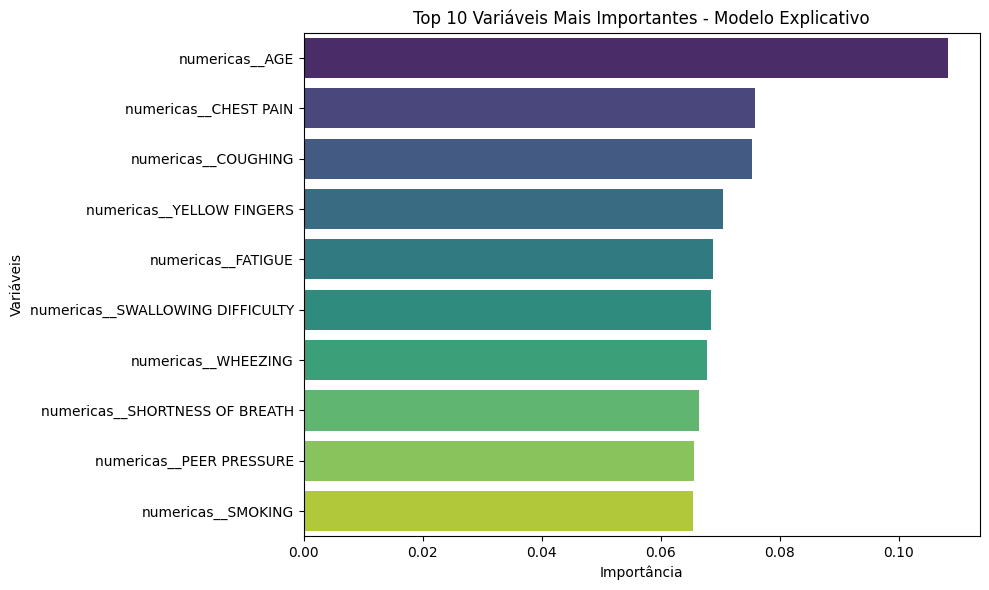

In [289]:
# Importância das variáveis com o melhor modelo do tipo árvore
if hasattr(melhor_modelo_final.named_steps['classificador'], 'feature_importances_'):
    modelo_explicativo = melhor_modelo_final
else:
    modelo_explicativo = modelos_ajustados.get('Extra Trees', modelos_ajustados.get('Random Forest', modelos_treinados['Random Forest']))

nomes_features = modelo_explicativo.named_steps['preprocessador'].get_feature_names_out()
importancias = modelo_explicativo.named_steps['classificador'].feature_importances_

importancias_df = pd.DataFrame({
    'Variável': nomes_features,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False).head(10)

display(importancias_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importancias_df,
    x='Importância',
    y='Variável',
    hue='Variável',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Variáveis Mais Importantes - Modelo Explicativo')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

,Variável,Impacto médio SHAP
11,numericas__ALCOHOL CONSUMING,0.027265
5,numericas__ANXIETY,0.021853
9,numericas__ALLERGY,0.017633
10,numericas__WHEEZING,0.016260
8,numericas__FATIGUE,0.015293
13,numericas__SHORTNESS OF BREATH,0.014789
4,numericas__YELLOW FINGERS,0.014581
14,numericas__SWALLOWING DIFFICULTY,0.014137
7,numericas__CHRONIC DISEASE,0.014034
12,numericas__COUGHING,0.013196


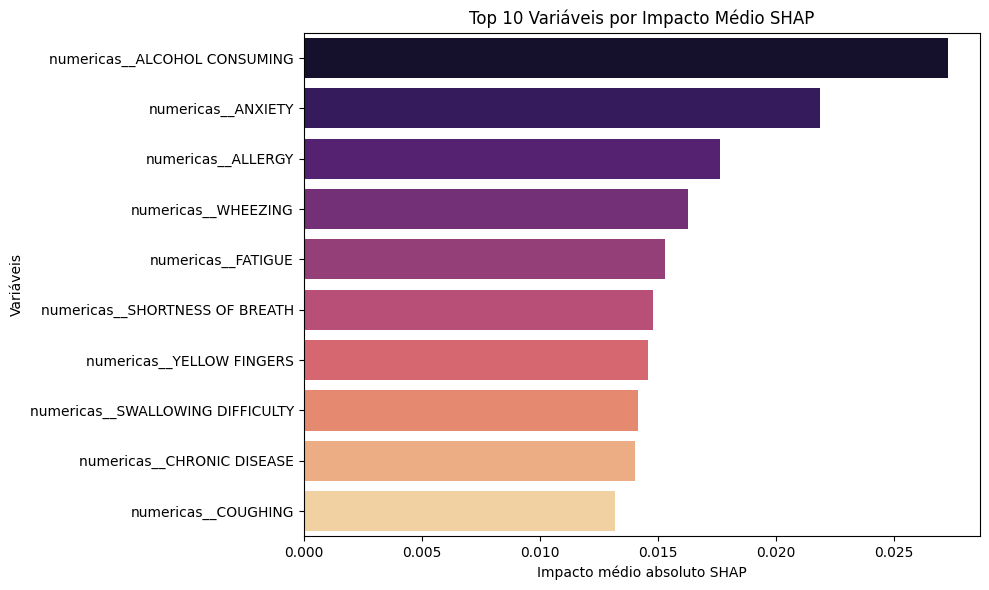

In [290]:
# Explicabilidade com SHAP usando o conjunto de validação
if shap is None:
    print('SHAP não está instalado no ambiente atual.')
else:
    X_val_transformado = modelo_explicativo.named_steps['preprocessador'].transform(X_val)

    if hasattr(X_val_transformado, 'toarray'):
        X_val_transformado = X_val_transformado.toarray()

    amostra_validacao = X_val_transformado[: min(200, len(X_val_transformado))]

    explicador = shap.TreeExplainer(modelo_explicativo.named_steps['classificador'])
    shap_values = explicador.shap_values(amostra_validacao)

    if isinstance(shap_values, list):
        shap_classe_positiva = shap_values[1]
    elif getattr(shap_values, 'ndim', 0) == 3:
        shap_classe_positiva = shap_values[:, :, 1]
    else:
        shap_classe_positiva = shap_values

    shap_importancia_df = pd.DataFrame({
        'Variável': nomes_features,
        'Impacto médio SHAP': np.abs(shap_classe_positiva).mean(axis=0)
    }).sort_values(by='Impacto médio SHAP', ascending=False).head(10)

    display(shap_importancia_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=shap_importancia_df,
        x='Impacto médio SHAP',
        y='Variável',
        hue='Variável',
        palette='magma',
        legend=False
    )

    plt.title('Top 10 Variáveis por Impacto Médio SHAP')
    plt.xlabel('Impacto médio absoluto SHAP')
    plt.ylabel('Variáveis')
    plt.tight_layout()
    plt.show()

## Conclusões Críticas

O notebook cobre o fluxo técnico esperado para um projeto de classificação com Machine Learning: exploração dos dados, limpeza, pré-processamento, análise de correlação, separação entre treino, validação e teste, treinamento com múltiplos modelos, ajuste de hiperparâmetros, avaliação final e explicabilidade.

A comparação entre **Regressão Logística**, **KNN**, **Random Forest** e **Extra Trees** mostrou que este dataset tem sinal preditivo limitado. Em termos simples, os dados não se separam com clareza: pacientes com e sem câncer parecem muito parecidos para o modelo. Por isso, a **accuracy** não sobe muito e não deve ser a métrica principal.

Neste problema, o erro mais perigoso é o **falso negativo**: quando o modelo diz que a pessoa não tem câncer, mas ela tem. Em saúde, isso é mais grave do que um falso positivo, porque pode atrasar exame, encaminhamento e tratamento. Por isso, as decisões do notebook priorizam **recall** e a contagem de falsos negativos.

O ajuste de limiar foi feito para manter uma sensibilidade alta na validação. Em linguagem simples: o modelo foi configurado para "acender o alerta" com mais facilidade, porque é melhor mandar alguns casos a mais para revisão do que deixar um caso suspeito passar despercebido. Ao baixar um pouco o limiar, dá para reduzir os falsos negativos, mas isso também aumenta os falsos positivos. Em triagem médica, esse é o trade-off esperado.

Mesmo assim, este dataset tem limitações importantes. Ele usa variáveis simples de questionário, quase todas binárias, sem exames laboratoriais, sem imagem, sem histórico clínico detalhado e sem sinais mais ricos que normalmente ajudam um médico a distinguir melhor os casos. Por isso, o modelo consegue apoiar a triagem, mas não consegue atingir uma precisão muito alta como se estivesse trabalhando com dados clínicos mais completos.

O modelo pode ser usado na prática como uma camada de **pré-triagem** para chamar atenção da equipe médica para casos que merecem revisão. Ele não deve ser tratado como diagnóstico final. A decisão clínica precisa continuar com o(a) médico(a), que deve considerar contexto, exame físico, histórico e confirmação diagnóstica antes de qualquer conduta.

As etapas de explicabilidade com **feature importance** e **SHAP** ajudam a mostrar quais variáveis mais influenciam a previsão. Isso melhora a auditabilidade e a discussão técnica do modelo no relatório final, mas não elimina o risco de viés, erro de generalização ou limitação do conjunto de dados.
